This part of the project requires Ollama to be installed anbd running on your computer to work. https://ollama.com/

In [1]:
# Imports

import ollama
from datasets import load_dataset
from sklearn.metrics import (accuracy_score,balanced_accuracy_score,f1_score,matthews_corrcoef,cohen_kappa_score,confusion_matrix,classification_report)
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

c:\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Should work for all models from ollama.com/search
# Selected models:
# gemma3:270m 290Mb
# gemma3:4b 3.3Gb

models = ["gemma3:270m", "gemma3:4b"]

# Options for generation. temperature=0 -> No randomness
custom_options = {
    "temperature": 0,
}

In [3]:
# Ollama has to be running in a console
# "ollama serve"

# Cheks if selected models are downloaded, if not downloads them. You need to have Ollama installed on your computer for this code to work. 
# If you're having problems downloading the models automatically, you can manually download them with the console with "ollama pull [model name]".
# To delete the models after use "ollama rm [model name]"
for model in models:
    try:
        ollama.show(model)
    except ollama.ResponseError as e:
        print("Error:", e.error)
        print(f"Downloading model: {model}")
        ollama.pull(model)
    else:
        print(f"""Model "{model}" found.""")
    

Model "gemma3:270m" found.
Model "gemma3:4b" found.


In [4]:
# Load dataset

sample_size = 100
dataset = load_dataset("dair-ai/emotion", "split")
test_data = dataset["test"].select(range(sample_size))  
texts = test_data["text"]
label_map = {0: "sadness", 1: "joy", 2: "love", 3: "anger", 4: "fear", 5: "surprise"}
true_labels = [label_map[l] for l in test_data['label']]
emotion_labels = list(label_map.values())

In [ ]:
# LLM Response formatting

from pydantic import BaseModel, Field
from typing import Literal
import json

# The LLM should give their response in a JSON conforming to these formats: 

class respose_format(BaseModel):
    emotion: Literal["sadness", "joy", "love", "anger", "fear", "surprise"] = Field(
        description="The overall sentiment present in the text."
    )

class CoT_respose_format(BaseModel):
    reasoning: str = Field(
        description="Use chain-of-thought reasoning to determine which emotion of the six base emotions(sadness, joy, love, anger, fear, surprise) the text evokes."
    )
    emotion: Literal["sadness", "joy", "love", "anger", "fear", "surprise"] = Field(
        description="The overall sentiment present in the text."
    )


In [ ]:
def classify_emotion(model, text, format):
    output = ollama.chat(
        model=model,
        messages=[
            {
            'role': 'system',
            'content': 'You are an expert sentiment analysis AI. Your task is to accurately analyze what emotion from the six base emotions ("sadness", "joy", "love", "anger", "fear", "surprise") a given text conveys.',
            },
            {
            'role': 'user',
            'content': f'Classify the predominant emotion in the following text: "{text}".',
            },
        ],
        format=format.model_json_schema(),
        options=custom_options,
    )
    return output

In [8]:
# Prediction loop without Chain-of-Thought

metrics_dict = {}
conf_matrices = {}
predictions_dict = {}

label_str = ", ".join(emotion_labels)
for model in models:
    
    predictions = []

    # Go through and predict emotion in dataset line by line
    for i,text in enumerate(texts):
        print(f"""Analyzing line {i+1}/{sample_size}. With model "{model}" without CoT.""", end="\r")
        
        response = classify_emotion(model=model, text=text, format=respose_format)

        output = json.loads(response["message"]["content"])
        predictions.append(output["emotion"])
    print()

    # Store predictions
    predictions_dict[model] = {
        "predictions": predictions,
    }

    # Analyze results
    acc = accuracy_score(true_labels, predictions)
    bal_acc = balanced_accuracy_score(true_labels, predictions)
    f1 = f1_score(true_labels, predictions, average='weighted', zero_division=0)
    mcc = matthews_corrcoef(true_labels, predictions)
    kappa = cohen_kappa_score(true_labels, predictions)

    # Full report for class-level precision & recall
    report = classification_report(true_labels, predictions, labels=emotion_labels, zero_division=0)
    print(report)

    # Store metrics
    metrics_dict[model] = {
        "accuracy": acc,
        "balanced_accuracy": bal_acc,
        "f1_weighted": f1,
        "mcc": mcc,
        "cohen_kappa": kappa,
        "report": report
    }

    # Store confusion matrix
    cm = confusion_matrix(true_labels, predictions, labels=emotion_labels)
    conf_matrices[model] = cm


Analyzing line 100/100. With model "gemma3:270m" without CoT.
              precision    recall  f1-score   support

     sadness       0.36      1.00      0.53        32
         joy       1.00      0.19      0.32        31
        love       1.00      0.20      0.33         5
       anger       1.00      0.18      0.30        17
        fear       1.00      0.08      0.15        12
    surprise       0.00      0.00      0.00         3

    accuracy                           0.43       100
   macro avg       0.73      0.28      0.27       100
weighted avg       0.77      0.43      0.36       100

Analyzing line 100/100. With model "gemma3:4b" without CoT.
              precision    recall  f1-score   support

     sadness       0.67      0.69      0.68        32
         joy       0.92      0.71      0.80        31
        love       0.40      0.40      0.40         5
       anger       0.73      0.65      0.69        17
        fear       0.62      0.67      0.64        12
    surpri

In [9]:
# Prediction loop with Chain-of-Thought

for model in models:
    
    reasonings = []
    predictions = []

    # Go through and predict emotion in dataset line by line
    for i,text in enumerate(texts):
        print(f"""Analyzing line {i+1}/{sample_size}. With model "{model}" with CoT.""", end="\r")

        response = classify_emotion(model=model, text=text, format=CoT_respose_format)

        output = json.loads(response["message"]["content"])
        reasonings.append(output["reasoning"])
        predictions.append(output["emotion"])
    print()

    # Analyze results
    acc = accuracy_score(true_labels, predictions)
    bal_acc = balanced_accuracy_score(true_labels, predictions)
    f1 = f1_score(true_labels, predictions, average='weighted', zero_division=0)
    mcc = matthews_corrcoef(true_labels, predictions)
    kappa = cohen_kappa_score(true_labels, predictions)

    # Full report for CoT version
    CoT_report = classification_report(true_labels, predictions, labels=emotion_labels, zero_division=0)
    print(CoT_report)

    # Store predictions and reasoning
    predictions_dict[model+"_CoT"] = {
        "predictions": predictions,
        "reasonings" : reasonings,
    }

    # Store metrics
    metrics_dict[model+"_CoT"] = {
        "accuracy": acc,
        "balanced_accuracy": bal_acc,
        "f1_weighted": f1,
        "mcc": mcc,
        "cohen_kappa": kappa,
        "report": CoT_report
    }

    # Store confusion matrix
    CoT_cm = confusion_matrix(true_labels, predictions, labels=emotion_labels)
    conf_matrices[model+"_CoT"] = CoT_cm

Analyzing line 100/100. With model "gemma3:270m" with CoT.
              precision    recall  f1-score   support

     sadness       0.33      1.00      0.50        32
         joy       1.00      0.06      0.12        31
        love       0.00      0.00      0.00         5
       anger       1.00      0.12      0.21        17
        fear       0.00      0.00      0.00        12
    surprise       0.00      0.00      0.00         3

    accuracy                           0.36       100
   macro avg       0.39      0.20      0.14       100
weighted avg       0.59      0.36      0.23       100

Analyzing line 100/100. With model "gemma3:4b" with CoT.
              precision    recall  f1-score   support

     sadness       0.61      0.62      0.62        32
         joy       0.88      0.68      0.76        31
        love       0.43      0.60      0.50         5
       anger       0.82      0.53      0.64        17
        fear       0.56      0.75      0.64        12
    surprise    

In [10]:
# Reasoning examples

from random import sample
n_samples = 3

samples = sample(range(sample_size-1),n_samples)
print(samples)
for model in models:
    reasonings = predictions_dict[model + "_CoT"]["reasonings"]
    predictions = predictions_dict[model + "_CoT"]["predictions"]
    
    print(f"Examples of reasoning for '{model}':")
    for sample in samples:
        print(f"  Text: {texts[sample]}")
        print(f"  Reasoning: {reasonings[sample]}")
        print(f"  Prediction: {predictions[sample]}")
        print(f"  True label: {true_labels[sample]}")
        print()
    print()


[47, 89, 86]
Examples of reasoning for 'gemma3:270m':
  Text: i feel like i had a rather productive weekend and i cant always say that no matter how much i get done
  Reasoning: sadness
  Prediction: sadness
  True label: joy

  Text: i feel so disappointed when my ex girlfriend doesn t call me back
  Reasoning: sadness
  Prediction: sadness
  True label: sadness

  Text: i feel like i am in paradise kissing those sweet lips make me feel like i dive into a magical world of love
  Reasoning: sadness
  Prediction: sadness
  True label: joy


Examples of reasoning for 'gemma3:4b':
  Text: i feel like i had a rather productive weekend and i cant always say that no matter how much i get done
  Reasoning: The text expresses a feeling of satisfaction and accomplishment ('productive weekend') coupled with a slight undercurrent of self-doubt ('cant always say that'). This combination leans heavily towards **joy** – a feeling of happiness and contentment stemming from a positive experience. The 

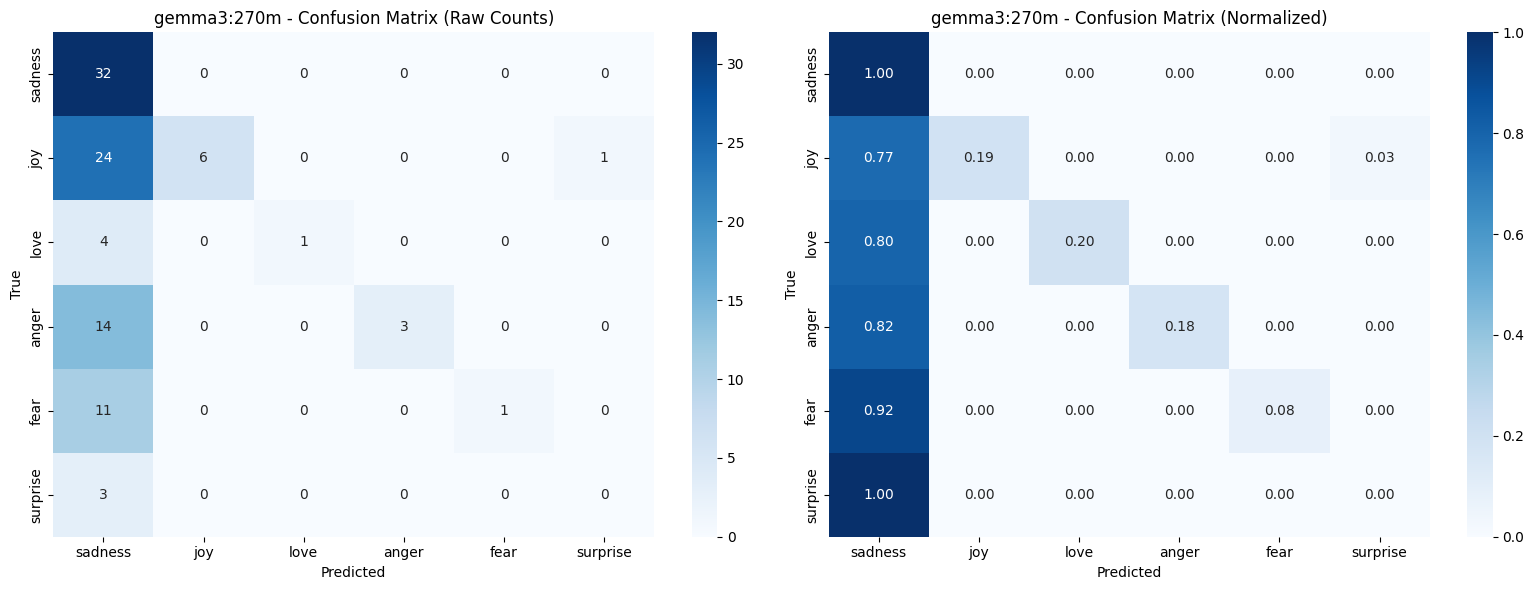

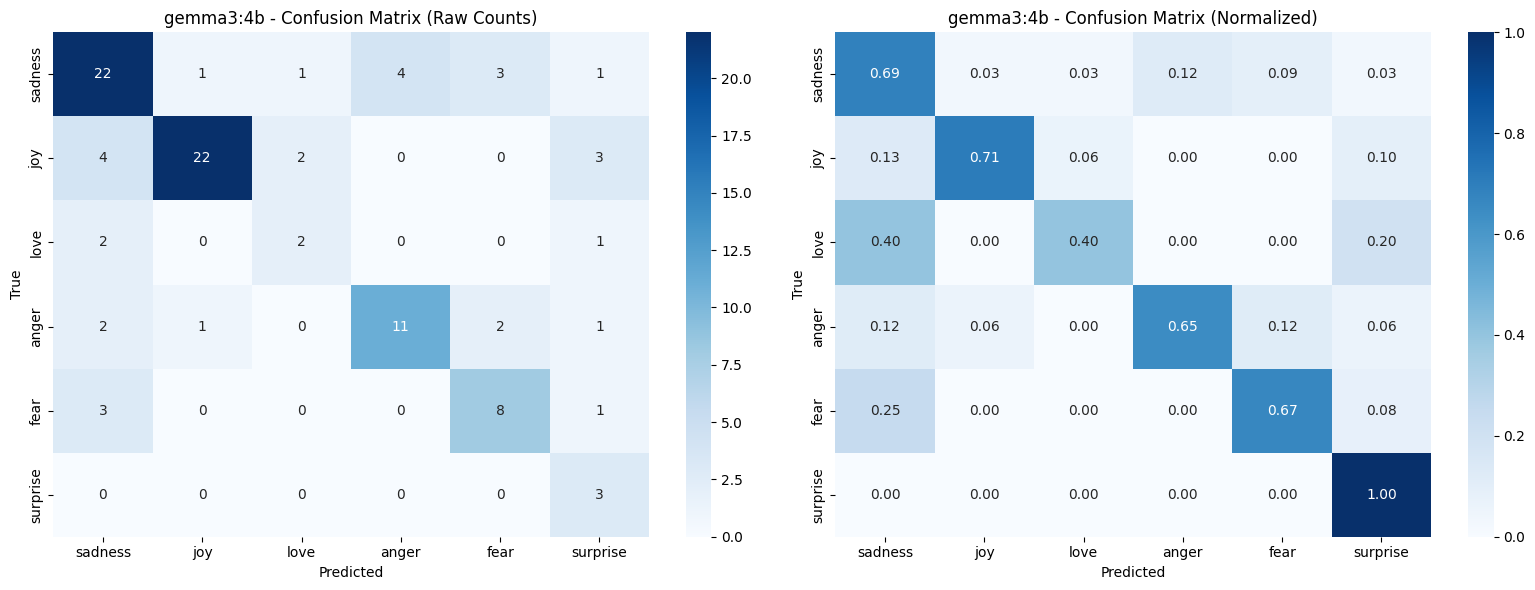

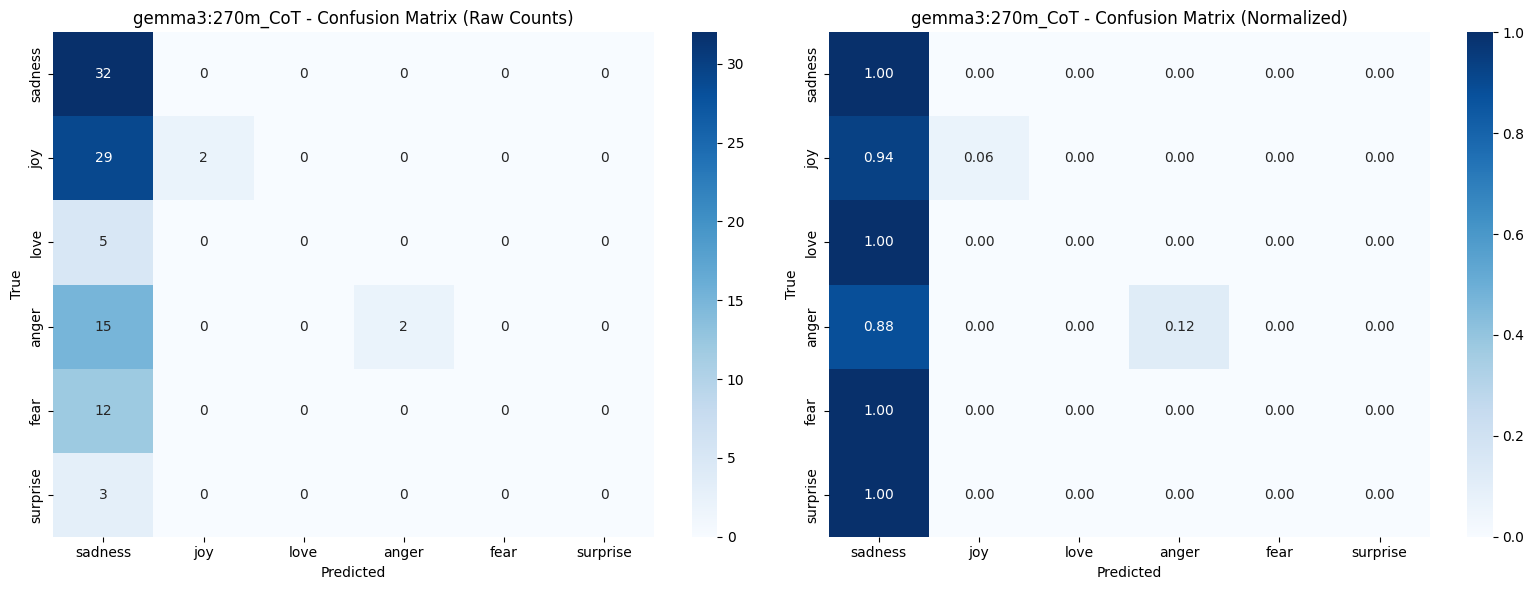

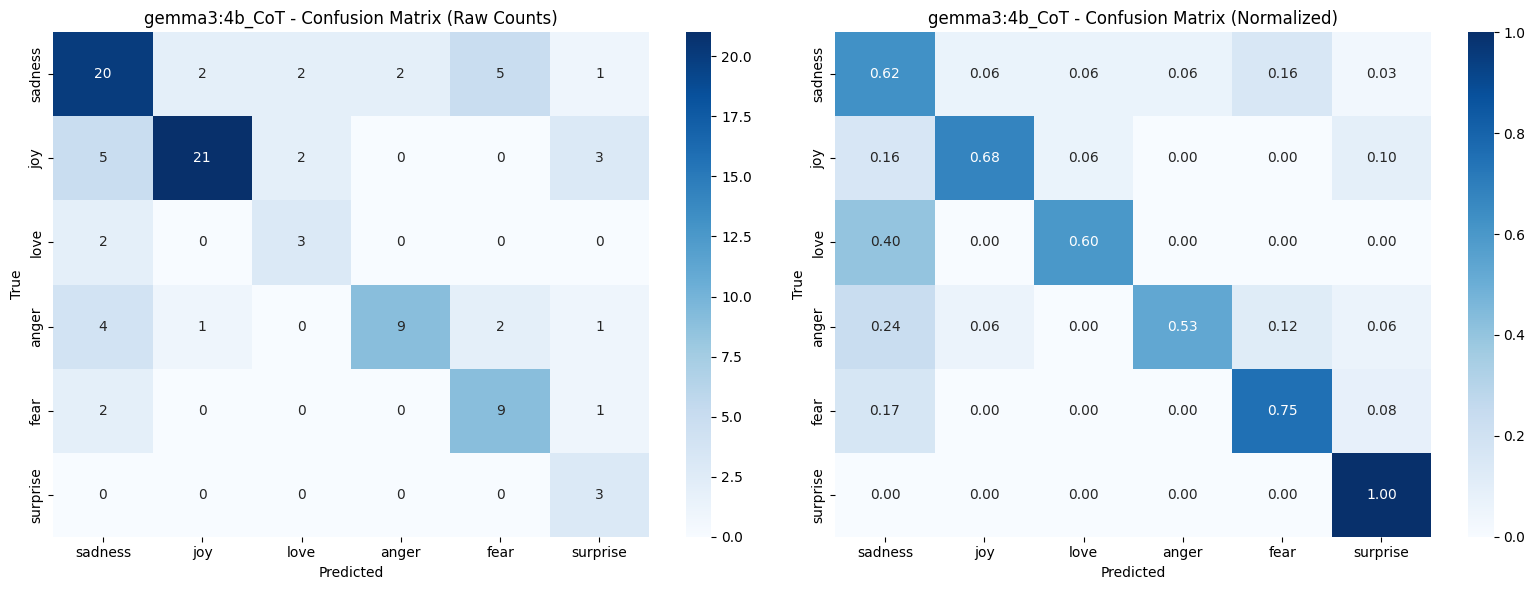

In [11]:
# Plot Raw & Normalized Confusion Matrices
for model_name, cm in conf_matrices.items():
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Raw counts
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=emotion_labels, yticklabels=emotion_labels, ax=axes[0])
    axes[0].set_title(f"{model_name} - Confusion Matrix (Raw Counts)")
    axes[0].set_xlabel("Predicted")
    axes[0].set_ylabel("True")

    # Normalized
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues",
                xticklabels=emotion_labels, yticklabels=emotion_labels, ax=axes[1])
    axes[1].set_title(f"{model_name} - Confusion Matrix (Normalized)")
    axes[1].set_xlabel("Predicted")
    axes[1].set_ylabel("True")

    plt.tight_layout()
    plt.show()

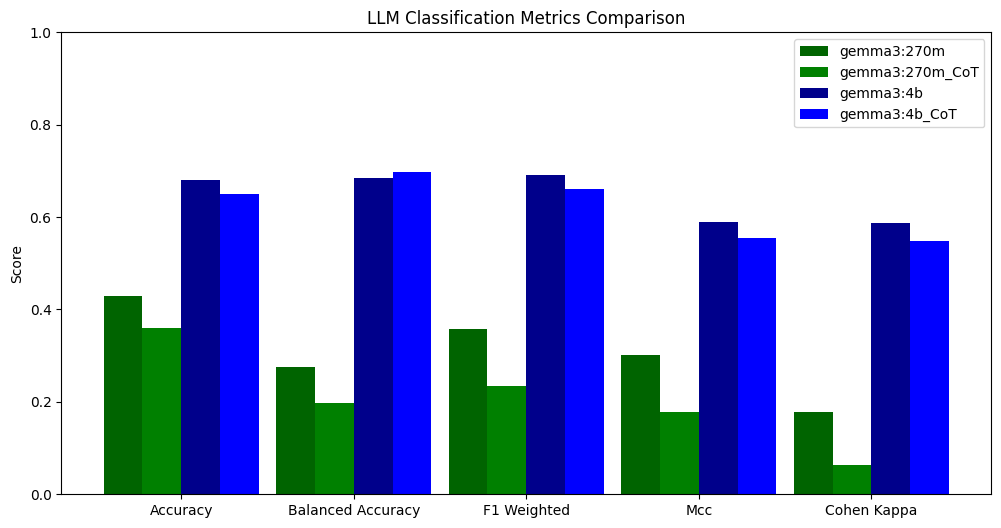

In [21]:
# Re order dictionary
order = []
for model in models:
    order.append(model)
    order.append(model + "_CoT")

metrics_dict = {key: metrics_dict[key] for key in order}

# 7. Plot Metrics Comparison (bar chart)
metric_names = ["accuracy", "balanced_accuracy", "f1_weighted", "mcc", "cohen_kappa"]
bar_colors = ['darkgreen', 'green', 'darkblue', 'blue']
x = np.arange(len(metric_names))
width = (1/len(metrics_dict))* 0.9

plt.figure(figsize=(12,6))
for i, model_name in enumerate(metrics_dict.keys()):
    scores = [metrics_dict[model_name][m] for m in metric_names]
    plt.bar(x + i*width, scores, width=width, label=model_name, color=bar_colors[i])

plt.xticks(x + (width * 1.5), [m.replace("_", " ").title() for m in metric_names])
plt.ylim(0, 1)
plt.ylabel("Score")
plt.title("LLM Classification Metrics Comparison")
plt.legend()
plt.show()